In [1]:
import pandas as pd
from math import ceil
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose


df = pd.read_csv('../../Neuronales_Netz/Fahrradzaehlung_komplett_rolling_mean_int.csv',
                 sep=',')
df['time'] = pd.to_datetime(df['time'])
df['days'] = df['time'].dt.date

df = pd.DataFrame(df.groupby('days')['rhenusallee'].sum())
header = 'rhenusallee'

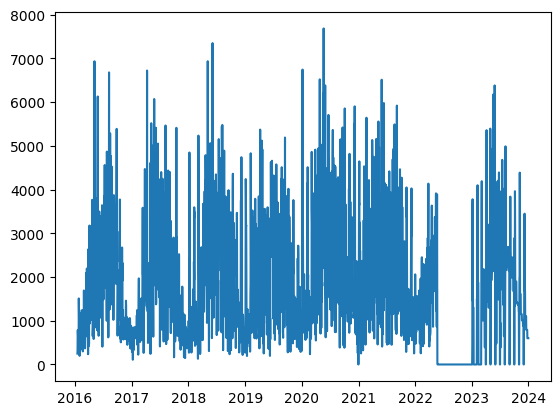

In [2]:
plt.plot(df[header])

In [3]:
df.index = pd.date_range(start=df.index[0], periods=len(df), freq='D')

In [4]:
#probiere logged first differences
from sklearn.preprocessing import MinMaxScaler
import numpy as np
maximum = max(df[header])
scaler = MinMaxScaler(feature_range=(1,maximum))
data = df[[header]]
model=scaler.fit(data)
scaled_data=model.transform(data)
df['scaled'] = scaled_data
df['log'] = np.log(df['scaled'])

In [5]:

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error
start_date= '2023-03-17'
end_date = '2023-12-31'
future_date='2024-02-28'
#Log Likelyhood: hoch, AIC: niedrig



Seasonal ARIMA

In [6]:
df_unstack = df[[header]]
df_unstack = df_unstack.set_index([df.index.year, df.index.month])
df_unstack.index.rename(['year', 'month'], inplace=True)
df_unstack = df_unstack.groupby(['year', 'month'])[header].apply(lambda x : x.astype(int).sum())
df_unstack = df_unstack.unstack(['month'])
df_unstack

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2016,11918,23721,31036,54695,80139,62739,85780,92188,86226,42418,27757,23479
2017,18692,25280,56679,55678,81122,84859,82669,80196,56358,51725,32953,18739
2018,36688,35351,45504,76593,85407,84383,93652,83268,68023,58944,44976,39953
2019,38564,56375,52031,67084,68282,79959,76535,75720,61974,57198,40787,36277
2020,49389,42502,73733,89259,105897,89059,103773,85952,86655,62461,60737,55904
2021,49459,66925,65187,72094,70694,76759,72423,76233,78908,56953,42956,42556
2022,34320,35565,61557,52053,59368,0,0,0,0,0,0,0
2023,16453,20983,54188,68836,92955,86954,69594,68301,58722,48827,39370,33001


Monatlich


In [7]:
df_month = df
df_month.set_index([df_month.index.year, df_month.index.month])
df_month['month'] = df_month.index.month
df_month['year'] = df_month.index.year
df_month = df_month.groupby(['year', 'month']).sum().reset_index()
monthly_pattern = df_month.groupby('month')[header].mean()
print(monthly_pattern)

month
1     31935.375
2     38337.750
3     54989.375
4     67036.500
5     80483.000
6     70589.000
7     73053.250
8     70232.250
9     62108.250
10    47315.750
11    36192.000
12    31238.625
Name: rhenusallee, dtype: float64


In [8]:
df_month.index

RangeIndex(start=0, stop=96, step=1)

In [9]:
df_month['year-month'] = df_month['year'].astype(str) + '-' + df_month['month'].astype(str).str.zfill(2)
tmp = pd.DataFrame()
tmp['year-month'] =  df_month['year-month']
tmp[header] = df_month[header]
df_month = tmp

In [10]:
df_month['year-month'] = pd.to_datetime(df_month['year-month'])
df_month.index = df_month['year-month']
df_month

,year-month,rhenusallee
year-month,,
2016-01-01,2016-01-01,11918
2016-02-01,2016-02-01,23721
2016-03-01,2016-03-01,31036
2016-04-01,2016-04-01,54695
2016-05-01,2016-05-01,80139
...,...,...
2023-08-01,2023-08-01,68301
2023-09-01,2023-09-01,58722
2023-10-01,2023-10-01,48827


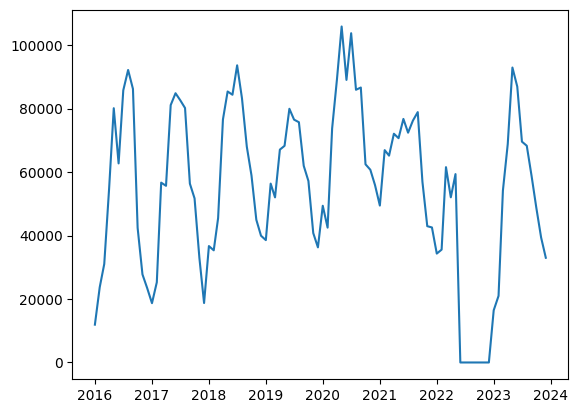

In [11]:
plt.plot(df_month[header])

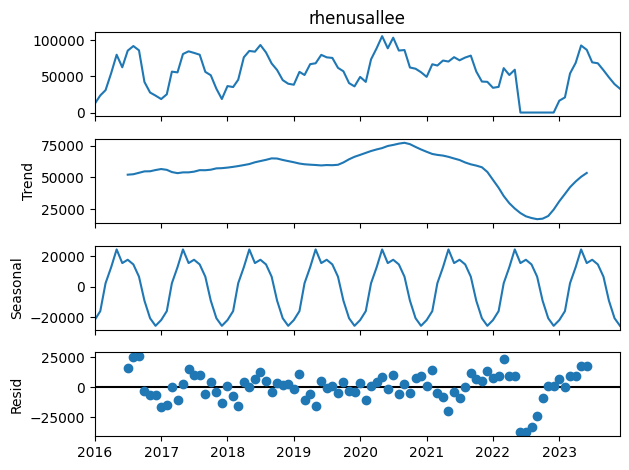

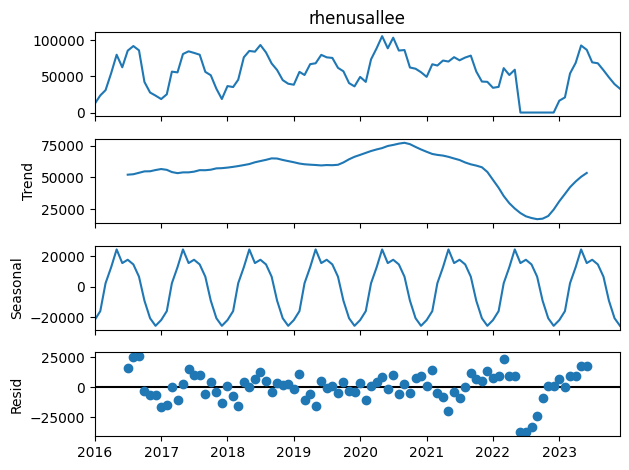

In [12]:
decomposition = seasonal_decompose(df_month[header], period=12)
decomposition.plot()

In [13]:
result = adfuller(df_month[header])
print("Test statistic = {:.4f}".format(result[0]))
print("p-value = {:.4f}".format(result[1]))

Test statistic = -5.0697
p-value = 0.0000


In [14]:
maximum = max(df_month[header])
scaler = MinMaxScaler(feature_range=(1,maximum))
data = df_month[[header]]
model=scaler.fit(data)
scaled_data=model.transform(data)
df_month['scaled'] = scaled_data
df_month['log'] = np.log(df_month['scaled'])
df_month

,year-month,rhenusallee,scaled,log
year-month,,,,
2016-01-01,2016-01-01,11918,11918.887457,9.385880
2016-02-01,2016-02-01,23721,23721.775999,10.074149
2016-03-01,2016-03-01,31036,31036.706923,10.342926
2016-04-01,2016-04-01,54695,54695.483508,10.909536
2016-05-01,2016-05-01,80139,80139.243236,11.291521
...,...,...,...,...
2023-08-01,2023-08-01,68301,68301.355024,11.131685
2023-09-01,2023-09-01,58722,58722.445480,10.980577
2023-10-01,2023-10-01,48827,48827.538920,10.796050


In [15]:
#Aufteilung Trainings- und Testdaten

end_train = ceil(len(df_month) * 0.9)
df_train = df_month.iloc[:end_train]
df_test = df_month.iloc[end_train:]

In [16]:
df_train.loc[:,'differences'] = df_train.loc[:,header].diff(periods=12)
result = adfuller(df_train['differences'].dropna())
print("Test statistic = {:.4f}".format(result[0]))
print("P-value = {:.4f}".format(result[1]))

Test statistic = -0.4241
P-value = 0.9060


C:\Users\caddowallace\AppData\Local\Temp\ipykernel_10440\2308934689.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train.loc[:,'differences'] = df_train.loc[:,header].diff(periods=12)


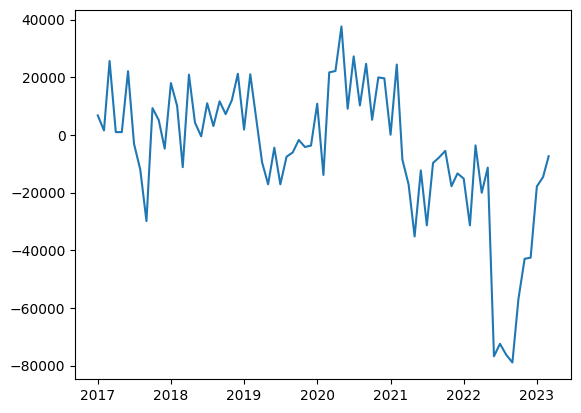

In [17]:
plt.plot(df_train['differences'])

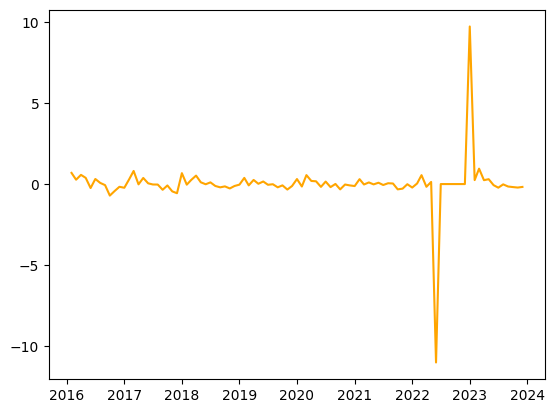

In [18]:
df_month['first_logged_diff'] = df_month['log'].diff().dropna()

plt.plot(df_month['first_logged_diff'], color='orange')
plt.show()

In [19]:
result = adfuller(df_month['first_logged_diff'].dropna())
print("Test statistic = {:.4f}".format(result[0]))
print("P-value = {:.4f}".format(result[1]))

Test statistic = -5.7286
P-value = 0.0000


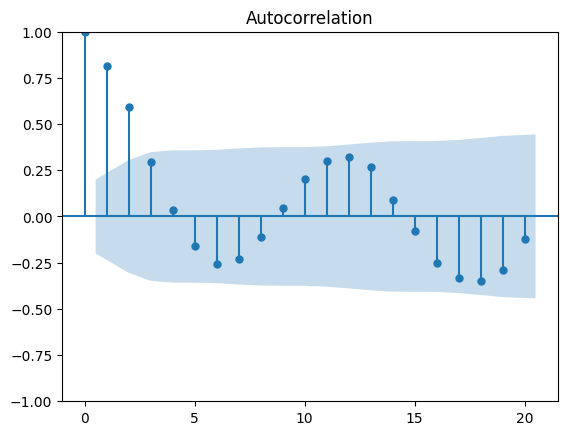

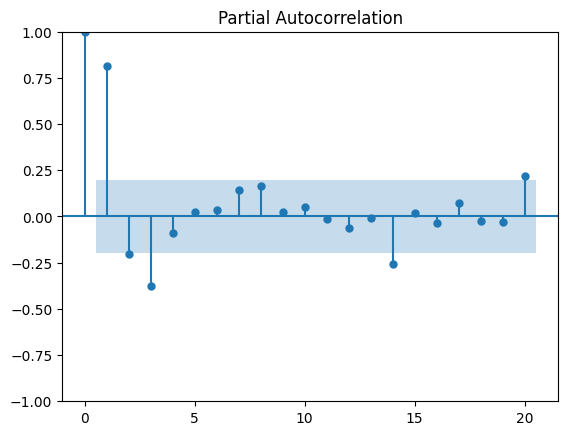

In [20]:
plot_acf(df_month[header])
plot_pacf(df_month[header])
plt.show()

In [21]:
#Mittelwertbereinigung
df_month['month'] = df_month['year-month'].dt.month
df_month['monthly_mean'] = df_month.groupby('month')['log'].transform('mean')
df_month['cleaned_by_mean'] = df_month['log'] - df_month['monthly_mean']
display(df_month)

,year-month,rhenusallee,scaled,log,first_logged_diff,month,monthly_mean,cleaned_by_mean
year-month,,,,,,,,
2016-01-01,2016-01-01,11918,11918.887457,9.385880,NaN,1,10.257539,-0.871659
2016-02-01,2016-02-01,23721,23721.775999,10.074149,0.688269,2,10.478017,-0.403868
2016-03-01,2016-03-01,31036,31036.706923,10.342926,0.268777,3,10.886806,-0.543880
2016-04-01,2016-04-01,54695,54695.483508,10.909536,0.566611,4,11.097675,-0.188139
2016-05-01,2016-05-01,80139,80139.243236,11.291521,0.381985,5,11.281195,0.010326
...,...,...,...,...,...,...,...,...
2023-08-01,2023-08-01,68301,68301.355024,11.131685,-0.018754,8,9.877903,1.253782
2023-09-01,2023-09-01,58722,58722.445480,10.980577,-0.151108,9,9.761576,1.219001
2023-10-01,2023-10-01,48827,48827.538920,10.796050,-0.184528,10,9.529503,1.266547


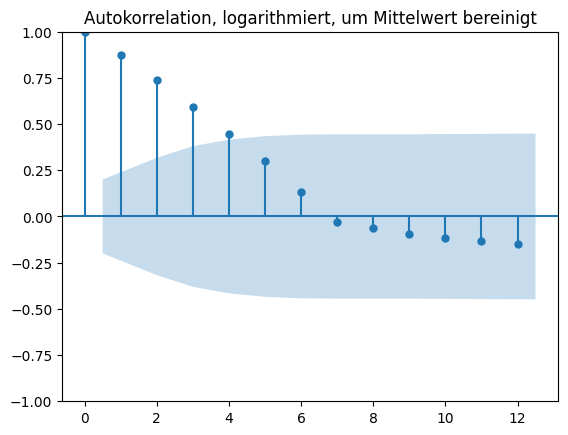

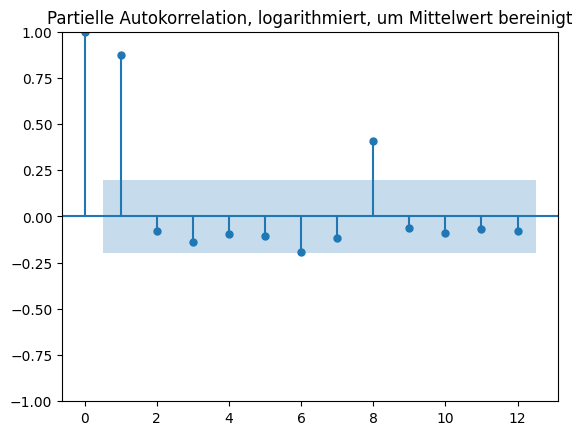

In [22]:
lags  = 12
plot_acf(df_month['cleaned_by_mean'], title='Autokorrelation, logarithmiert, um Mittelwert bereinigt', lags=lags)
plot_pacf(df_month['cleaned_by_mean'], title='Partielle Autokorrelation, logarithmiert, um Mittelwert bereinigt', lags=lags)
plt.show()

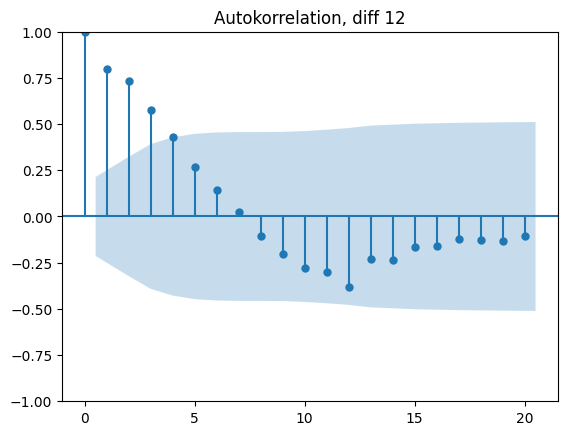

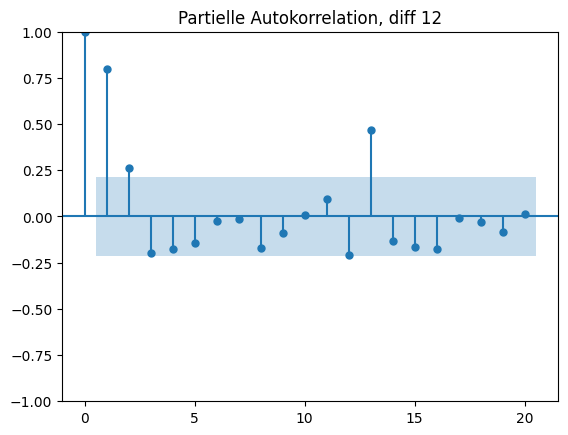

In [23]:
diffs = df_month[header].diff(periods=lags).dropna()
plot_acf(diffs[:], title='Autokorrelation, diff {:}'.format(lags))
plot_pacf(diffs[:], title='Partielle Autokorrelation, diff {:}'.format(lags))
plt.show()

In [24]:
#lags seasonal: 1, lag sonst: 1

end_train = ceil(len(df_month) * 0.9)
df_train_seas = df_month.iloc[:end_train]
df_test_seas = df_month.iloc[end_train:]

df_train_seas = df_train_seas.asfreq('MS')

seasonal = 12
result1 = SARIMAX(df_train_seas['log'], order=(0, 0, 0),
                  seasonal_order=(0, 1, 0, seasonal)).fit()
result2 = SARIMAX(df_train_seas['log'], order=(0, 1, 0),
                  seasonal_order=(0, 1, 0, seasonal)).fit()
result3 = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 1, seasonal)).fit()
result4 = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result5 = SARIMAX(df_train_seas['log'], order=(1, 1, 0),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result6 = SARIMAX(df_train_seas['log'], order=(0, 0, 1),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result7 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, [0,1], seasonal)).fit()
result8 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(2, 1, 0, seasonal)).fit()
result9 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(3, 1, 0, seasonal)).fit()
result10 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, 3, seasonal)).fit()

results = [result1, result2, result3, result4, result5]
print('ARIMA (0,0,0)x(0,1,0,12) LL {:.4f}, AIC: {:.4f}'.format(result1.llf, result1.aic))
print('ARIMA (0,1,0)x(0,1,0,12) LL {:.4f}, AIC: {:.4f}'.format(result2.llf, result2.aic))
print('ARIMA (1,0,0)x(0,1,1,12) LL {:.4f}, AIC: {:.4f}'.format(result3.llf, result3.aic))
print('ARIMA (1,0,0)x(0,1,2,12) LL {:.4f}, AIC: {:.4f}'.format(result4.llf, result4.aic))
print('ARIMA (1,1,0)x(0,1,2,12) LL {:.4f}, AIC: {:.4f}'.format(result5.llf, result5.aic))
print('ARIMA (0,0,1)x(0,1,2,12) LL {:.4f}, AIC: {:.4f}'.format(result6.llf, result6.aic))
print('ARIMA (0,1,1)x(0,1,2,12) LL {:.4f}, AIC: {:.4f}'.format(result7.llf, result7.aic))
print('ARIMA (0,1,1)x(2,1,0,12) LL {:.4f}, AIC: {:.4f}'.format(result8.llf, result8.aic))
print('ARIMA (0,1,1)x(3,1,0,12) LL {:.4f}, AIC: {:.4f}'.format(result9.llf, result9.aic))
print('ARIMA (0,1,1)x(0,1,3,12) LL {:.4f}, AIC: {:.4f}'.format(result10.llf, result10.aic))

C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible st

ARIMA (0,0,0)x(0,1,0,12) LL -197.8494, AIC: 397.6988
ARIMA (0,1,0)x(0,1,0,12) LL -146.7423, AIC: 295.4847
ARIMA (1,0,0)x(0,1,1,12) LL -146.1277, AIC: 298.2553
ARIMA (1,0,0)x(0,1,2,12) LL -146.1248, AIC: 300.2496
ARIMA (1,1,0)x(0,1,2,12) LL -146.5199, AIC: 301.0397
ARIMA (0,0,1)x(0,1,2,12) LL -171.0243, AIC: 350.0486
ARIMA (0,1,1)x(0,1,2,12) LL -146.7300, AIC: 299.4601
ARIMA (0,1,1)x(2,1,0,12) LL -146.5201, AIC: 301.0403
ARIMA (0,1,1)x(3,1,0,12) LL -146.5164, AIC: 303.0328
ARIMA (0,1,1)x(0,1,3,12) LL -146.5189, AIC: 303.0379


In [25]:
print(result3.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                  log   No. Observations:                   87
Model:             SARIMAX(1, 0, 0)x(0, 1, [1], 12)   Log Likelihood                -146.128
Date:                              Mon, 10 Feb 2025   AIC                            298.255
Time:                                      23:15:39   BIC                            305.208
Sample:                                  01-01-2016   HQIC                           301.031
                                       - 03-01-2023                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8596      0.036     23.682      0.000       0.788       0.931
ma.S.L12      -0.16

In [34]:
start_date = '2023-04-01'
end_date = '2024-12-01'
results_final = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
y_pred_no_update = results_final.predict(start='2023-04-01', end='2024-12-01')
y_pred_no_update = pd.DataFrame(y_pred_no_update)
y_pred_no_update['unlogged'] = np.exp(y_pred_no_update['predicted_mean'])
y_pred_no_update['new_predict'] = scaler.inverse_transform(y_pred_no_update[['unlogged']])
print(y_pred_no_update)

C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


            predicted_mean      unlogged   new_predict
2023-04-01       10.774800  47800.922220  47800.373606
2023-05-01       10.881422  53179.160640  53178.662814
2023-06-01        1.843527      6.318782      5.318833
2023-07-01        1.835345      6.267294      5.267344
2023-08-01        1.842120      6.309900      5.309950
2023-09-01        1.848599      6.350913      5.350963
2023-10-01        1.790334      5.991453      4.991500
2023-11-01        1.743299      5.716171      4.716215
2023-12-01        1.741199      5.704177      4.704221
2024-01-01        9.696055  16253.368588  16252.522062
2024-02-01        9.905571  20041.703380  20040.892629
2024-03-01       10.777949  47951.698358  47951.151168
2024-04-01       10.646827  42058.937038  42058.334201
2024-05-01       10.756243  46922.027928  46921.471014
2024-06-01        1.459493      4.303779      3.303810
2024-07-01        1.451845      4.270986      3.271017
2024-08-01        1.458373      4.298958      3.298989
2024-09-01

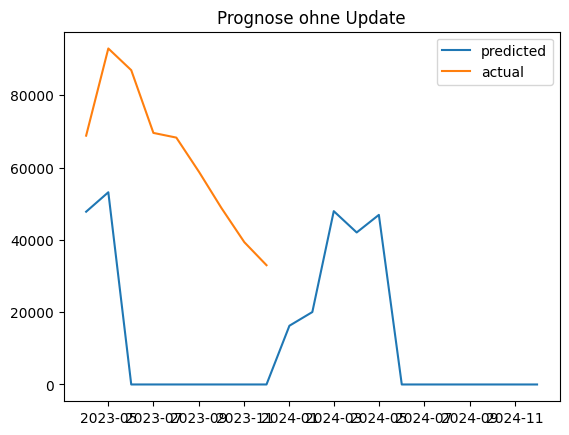

mean absolute error (mae): ARIMA: 51727.2561
mean squared error (mse): ARIMA: 3062359468.5918
mean absolute percentage error (mape): ARIMA: 0.8592


In [35]:
plt.plot(y_pred_no_update['new_predict'], label='predicted')
plt.plot(df_test_seas[header], label='actual')

plt.title('Prognose ohne Update')
plt.legend()
plt.show()

plt.show()
mape_bound = 10

df_test_seas.loc[:, 'intervals'] = (df_test_seas[header] > mape_bound).astype(int).diff().fillna(0).ne(0).cumsum()
df_test_seas.loc[:, 'group'] = df_test_seas[header].apply(lambda x: '≤ 10' if x <= mape_bound else '> 10')
df_test_seas.loc[:, 'predicted'] = y_pred_no_update.loc[start_date:end_date, 'new_predict']

greater = df_test_seas[df_test_seas['group'] == '> 10']
mape_arima = []
mape_simple = []

for name, group in greater.groupby('intervals'):
    mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))

mae_arima = np.mean(np.abs(df_test_seas[header] - y_pred_no_update.loc[start_date:'2023-12-01', 'new_predict']))
mse_arima = np.mean(np.square(df_test_seas[header] - y_pred_no_update.loc[start_date:'2023-12-01', 'new_predict']))
mape_arima = sum(mape_arima) / len(mape_arima)

print("mean absolute error (mae): ARIMA: {:.4f}".format(mae_arima))
print("mean squared error (mse): ARIMA: {:.4f}".format(mse_arima))
print("mean absolute percentage error (mape): ARIMA: {:.4f}".format(mape_arima))

In [37]:
arima = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, 2, seasonal), freq='MS')
result = arima.fit()
#print(result.summary())
model = SARIMAX(df_month['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, 2, seasonal), freq='MS')
result_new = model.filter(result.params)
y_pred_test = result_new.predict(start='2023-04-01', end='2024-12-01')

tmp = pd.DataFrame(y_pred_test)
tmp['unlogged'] = np.exp(tmp['predicted_mean'])
tmp['final_data'] = scaler.inverse_transform(tmp[['unlogged']])
tmp

C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,predicted_mean,unlogged,final_data
2023-04-01,10.774800,4.780092e+04,4.780037e+04
2023-05-01,11.242070,7.627271e+04,7.627243e+04
2023-06-01,2.399786,1.102082e+01,1.002092e+01
2023-07-01,11.265586,7.808757e+04,7.808731e+04
2023-08-01,11.158489,7.015686e+04,7.015652e+04
2023-09-01,11.138460,6.876571e+04,6.876536e+04
2023-10-01,10.924061,5.549572e+04,5.549524e+04
2023-11-01,10.750432,4.665020e+04,4.664964e+04
2023-12-01,10.580554,3.936190e+04,3.936127e+04
2024-01-01,18.361122,9.421806e+07,9.421895e+07


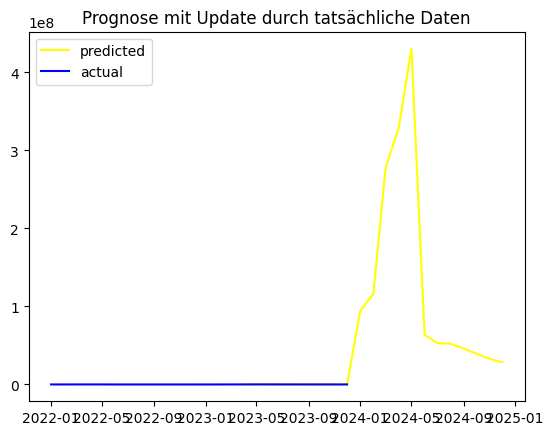

In [38]:
# Mergen der Daten
df_r = pd.concat([df_train_seas, tmp], axis=1)

df_r[header] = df_r[header].fillna(df_r['final_data'])
df_r = pd.DataFrame(df_r)
df_r.index = pd.to_datetime(df_r.index)
start_date = '2022-01-01'
end_date = '2024-12-01'
plt.title('Prognose mit Update durch tatsächliche Daten')
plt.plot(df_r.loc[start_date:end_date, 'final_data'],
            color='yellow', label='predicted')
plt.plot(df_month.loc[start_date:'2023-12-31', header], color='blue', label='actual')
plt.legend()
plt.show()

In [39]:
mape_bound = 10

df_test_seas.loc[:, 'intervals'] = (df_test_seas[header] > mape_bound).astype(int).diff().fillna(0).ne(0).cumsum()
df_test_seas.loc[:, 'group'] = df_test_seas[header].apply(lambda x: '≤ 10' if x <= mape_bound else '> 10')
df_test_seas.loc[:, 'predicted'] = df_r.loc[start_date:end_date, header]

greater = df_test_seas[df_test_seas['group'] == '> 10']
mape_arima = []
mape_simple = []

for name, group in greater.groupby('intervals'):
    mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))

mae_arima = np.mean(np.abs(df_test_seas[header] - df_r.loc[start_date:'2023-12-01', header]))
mse_arima = np.mean(np.square(df_test_seas[header] - df_r.loc[start_date:'2023-12-01', header]))
mape_arima = sum(mape_arima) / len(mape_arima)

print("mean absolute error (mae): ARIMA: {:.4f}".format(mae_arima))
print("mean squared error (mse): ARIMA: {:.4f}".format(mse_arima))
print("mean absolute percentage error (mape): ARIMA: {:.4f}".format(mape_arima))

mean absolute error (mae): ARIMA: 18373.6123
mean squared error (mse): ARIMA: 954935684.4989
mean absolute percentage error (mape): ARIMA: 0.2577
